In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("project1.ipynb")

# Midterm Project: Exploring USA County Health Rankings and Roadmaps

### Collaborators and Sources
In addition to recording your **collaborators** (TAs, peers, group members, roommates, etc.) on this homework in the cell below, you are required to **cite/indicate all external sources** used when finishing this assignment. 
External sources are defined as anything that is not considered course material, such as online sources (webpages, blog posts, etc.), content generated by AI systems, books, etc.

When using external sources, indicate what kind of external sources (e.g. stack overflow, WashU chatGPT, etc.) you used in the cell below and then provide more specific citations (such as links to webpages or in case of AI generated asnwers the actual sources (links provided by the AI system) and the prompt used to generate the answers) with your answer to **each specific problem**.  


Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process, **especially** when two or more submissions closely resemble each other. Working with each other is ok, as long as you cite who you worked with and you don't copy anyone's answers directly!

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line. 

### Submission instructions
* Submit this Python notebook, including your answers in the code cells as homework submission.
* **Feel free to add as many cells as you need to** — just make sure you don't change what we gave you. 
* **Does it spark joy?** Note that you will be partially graded on the presentation (_cleanliness, clarity, comments_) of your notebook so make sure you [Marie Kondo](https://lifehacker.com/marie-kondo-is-not-a-verb-1833373654) your notebook before submitting it.

## 1. Introduction

We are using the 2024 County Health Release National Data compiled and curated by the County Health Rankings & Roadmaps (CHR&R), a program of the University of Wisconsin Population Health Institute. It provides data at the county-level to enable analysis of the reasons for the differences in health within each community and across communities. (https://www.countyhealthrankings.org/).

For our midterm project this semester, the data (analytic_data2024.csv) and the data dictionary is already stored in this box folder (https://wustl.box.com/s/6sobk3ae12bup7ccp29y964q1pyuu0l7) for your convinence or you can also download it from https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation (2024 CHR CSV Analytic Data)

Our goal will be to use the clean dataset (analytic_data2024.csv) to gain some insight about US County Health Rankings & Roadmaps (CHR&R) characteristics and (_hopefully_) find some patterns in this data.

In general, we will be following the EDA process:
1. Get the data and gain **basic understanding**
2. **Wrangle** the data
3. **Profile** the data
4. Develop questions to investigate (form a **hypotheses**)
5. Use the data to **investigate** hypothesis
6. **Summarize** results and answer questions 
7. **Critically review** our workflow and discuss ethical concerns

In [2]:
# Load dataset
from os.path import exists
import pandas as pd

data_dir = 'utility/data'

assert exists(f'{data_dir}/analytic_data2024.csv'), 'Loan data file is missing.'

data = pd.read_csv(f'{data_dir}/analytic_data2024.csv')

C:\Users\apeddada\AppData\Local\Temp\ipykernel_34392\793279994.py:9: DtypeWarning: Columns (0,1,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,25

## 2. Getting Familiar with the Data

In this section, we will get a feel for our data and tidy it up so that we can analyize it later. 
Download the data from the source/link given above and be sure to save the data in a folder called `data` under the `utility` directory. Your final path should look like `utility/data/analytic_data2024.csv` -- if it doesn't **we will not be able to properly grade your assignment!**



<!-- BEGIN QUESTION -->

### Problem 1

Let's start by taking a look at our data and the README that includes essential information for the data. 

**Write-up!** Describe the data, answering questions including, but not limited to, these: Where does the data come from? How was it obtained? How many examples (rows) and features (columns) does the dataset have? What kinds of features are in the dataset -- numerical  (discrete/continuous) or categorical(ordinal/nominal)? What range of values does each feature  take? List five or more features you find the most relevant and would like to explore further. 
> **Hint**: Consider the steps of EDA; what would you like to know about this dataset. 

**Answer here:** (feel free to make multiple cells!)  

The dataset was produced by County Health Rankings & Roadmaps (CHR&R), a program of the University of Wisconsin Population Health Institute, but the data was gathered by many different sources including the USDA Food Environment Atlas and Institute of Museum and Library Services. 

They selected 5 measures to include in the summary score for Population Health and Well-being and 29 measures for Community Conditions 

The original data set contains 3195 rows and 770 columns.

The features include both continuous and discrete numerical variables and nominal categorical variables. Ranges include 0-100 for percentages and continuous numbers for counts. 

Features we find relevant: We would like to compare poor mental health days with poor physical health days. For this we would look at both the raw values of each feature (2) and the high/low confidence interval (2 for each, 4 total). 


### Problem 2

Data cleaning and processing: Let's do some data wrangling. 

**Write up!** Considering your description of the dataset from [Problem 1](#Problem-1), how should we clean this data?

Here are some initial instructions to get you started and feel free to do further cleaning if it makes sense for your data analytics:
- Retain only the following columns: 'State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name', 'State Abbreviation', 'Release Year' and all the '*_raw value'. Report any changes in data size or shape after each update or reduction.
> **Hint** You can use the `endswith()` function or regex to get the column names that end with a specific suffix.
- Remove the rows corresponding to the aggregate values for the entire US and one for each state and District of Columbia. **These rows have a “County FIPS Code” value of “000”.**
- Remove columns where over 10% of the values are missing values. This should bring the number of columns down to ~75.
> **Hint** Use the `df.dropna(axis=1, thresh=n)` method, where n is the minimum number of non-missing values a column must have to be retained. Given that a column should have at least 90% of its values present, how would you determine `n`?

- Keep only complete rows, i.e., remove rows with any missing value.
- Feel free to rename the columns, making them more meaningful.
- Drop the first row of the dataset.
- Covert the '*_raw value' columns to a numeric data type.
> **Hint** Use `lambda` and `pd.to_numeric`
- Based on the goals of your project, feel free to get rid of more features to keep your dataset more aligned with your project goals and further analysis.

**Do this!** In the cells below, **explain** and perform the steps that you need to prepare this data for further analysis. Make sure that your implementations and write-ups (for processing and analysis) are presented well and effectively describe your workflow. You should add comments and markdown cells for your documentation as you see fit!  


*Grading Note: Your work will be graded for _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report.*

> **Hint**: You can use our previous labs as examples of how you might do this. 
Also, you might want to come back to this step later on, since you might encounter problems with the data once you actually analyze it. Remember, you may add as many cells (for code and text) as you need below. Here — we gave you one for free!

**Write up:** Based on the data, we should clean the data by eliminating any columns with unfinished or missing data. We could also standardize the data if we wanted to, especially if we wanted to compare variables that had different data types. We could also check and remove outliers in order to make sure any analysis we do is actually accurate to the general trend. 


In [3]:
# this one is free!

In [4]:
#variable is created with all of the column names we want to keep along with all the raw value columns
initial= ['State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name', 'State Abbreviation', 'Release Year', 'Poor Physical Health Days CI low', 'Poor Physical Health Days CI high', 'Poor Mental Health Days CI low', 'Poor Mental Health Days CI high'] 
raw_value_col= [col for col in data.columns if col.endswith('raw value')]

#data set is changed to only have those columns
data= data[initial+raw_value_col]

#removes any row with a county FIPs code of 000
#data= data[data['County FIPS Code']!= '000']
#we actually decided to use the aggregate state values, so I commented this out in order to bring it back into the dataset.

#determine the threshold that results in only keeping columns with 90% of its values present
row_num=len(data)
threshold= int(.9*row_num)

#recompute all columns with raw value in the updated data set 
raw_value_col = [col for col in data.columns if col.endswith('raw value')]

#apply the threshold to the data set and remove any columns that don't apply
data= data.dropna(axis=1, thresh=threshold) 

#Covert the '*_raw value' columns to a numeric data type or replaces it if there's an error 
raw_value_col = [col for col in data.columns if col.endswith('raw value')]
data[raw_value_col]=data[raw_value_col].apply(lambda x: pd.to_numeric(x, errors='coerce'))

#Remove all other columbs except for the columns we want for our analysis
retain= ['State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name', 'State Abbreviation', 'Release Year', 'Poor Physical Health Days CI low', 'Poor Physical Health Days CI high', 'Poor Mental Health Days CI low', 'Poor Mental Health Days CI high', 'Poor Mental Health Days raw value', 'Poor Physical Health Days raw value']

data= data[retain]

print(data.columns)
data.head()

Index(['State FIPS Code', 'County FIPS Code', '5-digit FIPS Code', 'Name',
       'State Abbreviation', 'Release Year',
       'Poor Physical Health Days CI low', 'Poor Physical Health Days CI high',
       'Poor Mental Health Days CI low', 'Poor Mental Health Days CI high',
       'Poor Mental Health Days raw value',
       'Poor Physical Health Days raw value'],
      dtype='object')


,State FIPS Code,County FIPS Code,5-digit FIPS Code,Name,State Abbreviation,Release Year,Poor Physical Health Days CI low,Poor Physical Health Days CI high,Poor Mental Health Days CI low,Poor Mental Health Days CI high,Poor Mental Health Days raw value,Poor Physical Health Days raw value
0,statecode,countycode,fipscode,county,state,year,v036_cilow,v036_cihigh,v042_cilow,v042_cihigh,NaN,NaN
1,00,000,00000,United States,US,2024,3.2963255391,3.3962743587,4.7557014353,4.8785424603,4.817122,3.346300
2,01,000,01000,Alabama,AL,2024,3.6086452756,4.2608255303,5.4512176816,6.2874220004,5.869320,3.934735
3,01,001,01001,Autauga County,AL,2024,3.0834568712,4.8366868207,4.6670532858,6.8609250878,5.703204,3.910265
4,01,003,01003,Baldwin County,AL,2024,2.9592832871,4.5160493035,4.445590441,6.2737119961,5.373666,3.730943


**Explanation:** To clean the data I first defined the column names I wanted to keep which included the variables we were interested in and all the raw value columns. I then removed any columns with less than 90% of their rows filled out. With the raw values, I converted them to a numeric data type to make analysis and our future methods easier. I then removed all columns that weren't relevent to our questions. I chose not to remove the state data because we wanted to use it in our analysis 

### Problem 3

Formulating and Answering Questions Through Analysis and Visualizations 

**Do this!** Now that we cleaned up our data, we are ready to look into it. In this problem, we want to profile our data and explore its variables.

> **Hint**: Note that the way some data is stored does not necesarily mean that each column should correspond to a seperate variable. Feel free to define your own variables based on the input data. Looking at the dataset documentation (data dictionary) might be helpful to figure out meaningful representations. Also note that there are no right or wrong representations here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variable representations). Again, you might want to iterate over this step again later after doing some more exploration. 

> **Hint**: Recall from Lab 2, this step usually involves computing summary statistics and basic plots _where applicable_. Try plotting some of the data (with appropriate plots; remember the lecture content - some plots introduced in there ( we did not yet use in the lab or hw) could be useful). Then, highlight a few of the more interesting ones and discuss why you thought they were interesting — for both our sakes, **please only include the most interesting ones** in your actual submission!!  Again note that there are no right or wrong features to choose here (since it is your job to find something interesting in the data, it is also up to you to choose the data/variables to include). Just be sure to make a selection. You will not receive any credit by simply plotting everything!  

*Grading Note*: Your work will be graded for _creativity_ and _aesthetics_. Be creative in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures.* 

Once again, we have provided a _free_ cell for you to use; make as many as you need. Use text/markdown cells to describe what you are doing and what your findings are. 

In [5]:
# this one is also free!

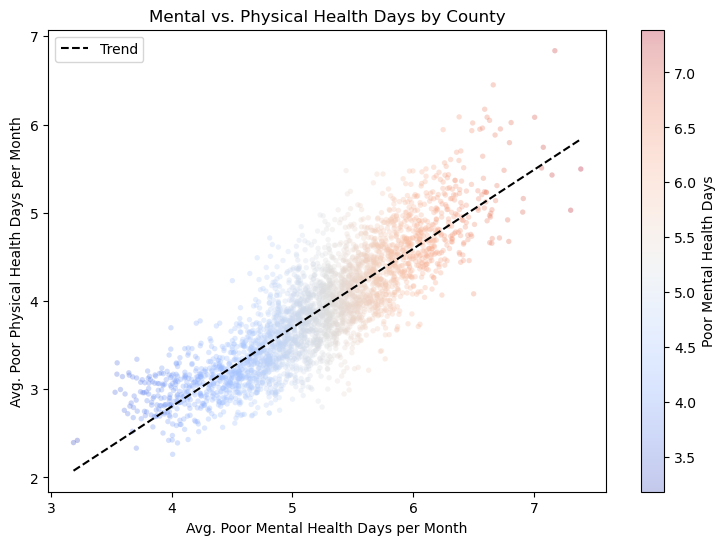

Correlation: 0.847


In [6]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns 
import numpy as np

#defining columns
mentalCol = 'Poor Mental Health Days raw value'
physicalCol = 'Poor Physical Health Days raw value'

#making the plot
fig, ax = plt.subplots(figsize=(9, 6))

#creating the scatter plot
scatter = ax.scatter(data[mentalCol], data[physicalCol], alpha=0.3, s=15, c=data[mentalCol], cmap='coolwarm', linewidths=0)

#calculating the slope and intercept
m, b = np.polyfit(data[mentalCol].dropna(), data[physicalCol].dropna(), 1)

#points for trendline
xVals = np.linspace(data[mentalCol].min(), data[mentalCol].max(), 100)
ax.plot(xVals, m * xVals + b, color='black', linewidth=1.5, linestyle='--', label='Trend')


#labels and formatting
ax.set_title('Mental vs. Physical Health Days by County')
ax.set_xlabel('Avg. Poor Mental Health Days per Month')
ax.set_ylabel('Avg. Poor Physical Health Days per Month')

ax.legend()
plt.colorbar(scatter, ax=ax, label='Poor Mental Health Days')

plt.show()

# Stat Summary
corr = data[[mentalCol, physicalCol]].corr().iloc[0, 1]
print(f"Correlation: {corr:.3f}")



**Explanation:** The following color-coded scatter plot explores the relationship between mental and physical health across various counties, where each point represents a specific locality. We can also calculate a linear regression trendline to visually demonstrate whether an increase in poor mental health days typically correlates with an increase in poor physical health days. Furthermore, we can determine the Pearson correlation coefficient to quantify the exact strength of this connection.


The scatter plot reveals a positive linear relationship between mental and physical health indicators at the county level. As the average number of poor mental health days per month increases, we can see that there is a proportional increase in poor physical health days. There is a high density of points along the regression line which suggests that factors impacting mental well being are likely closely linked to physical health outcomes within these communities.


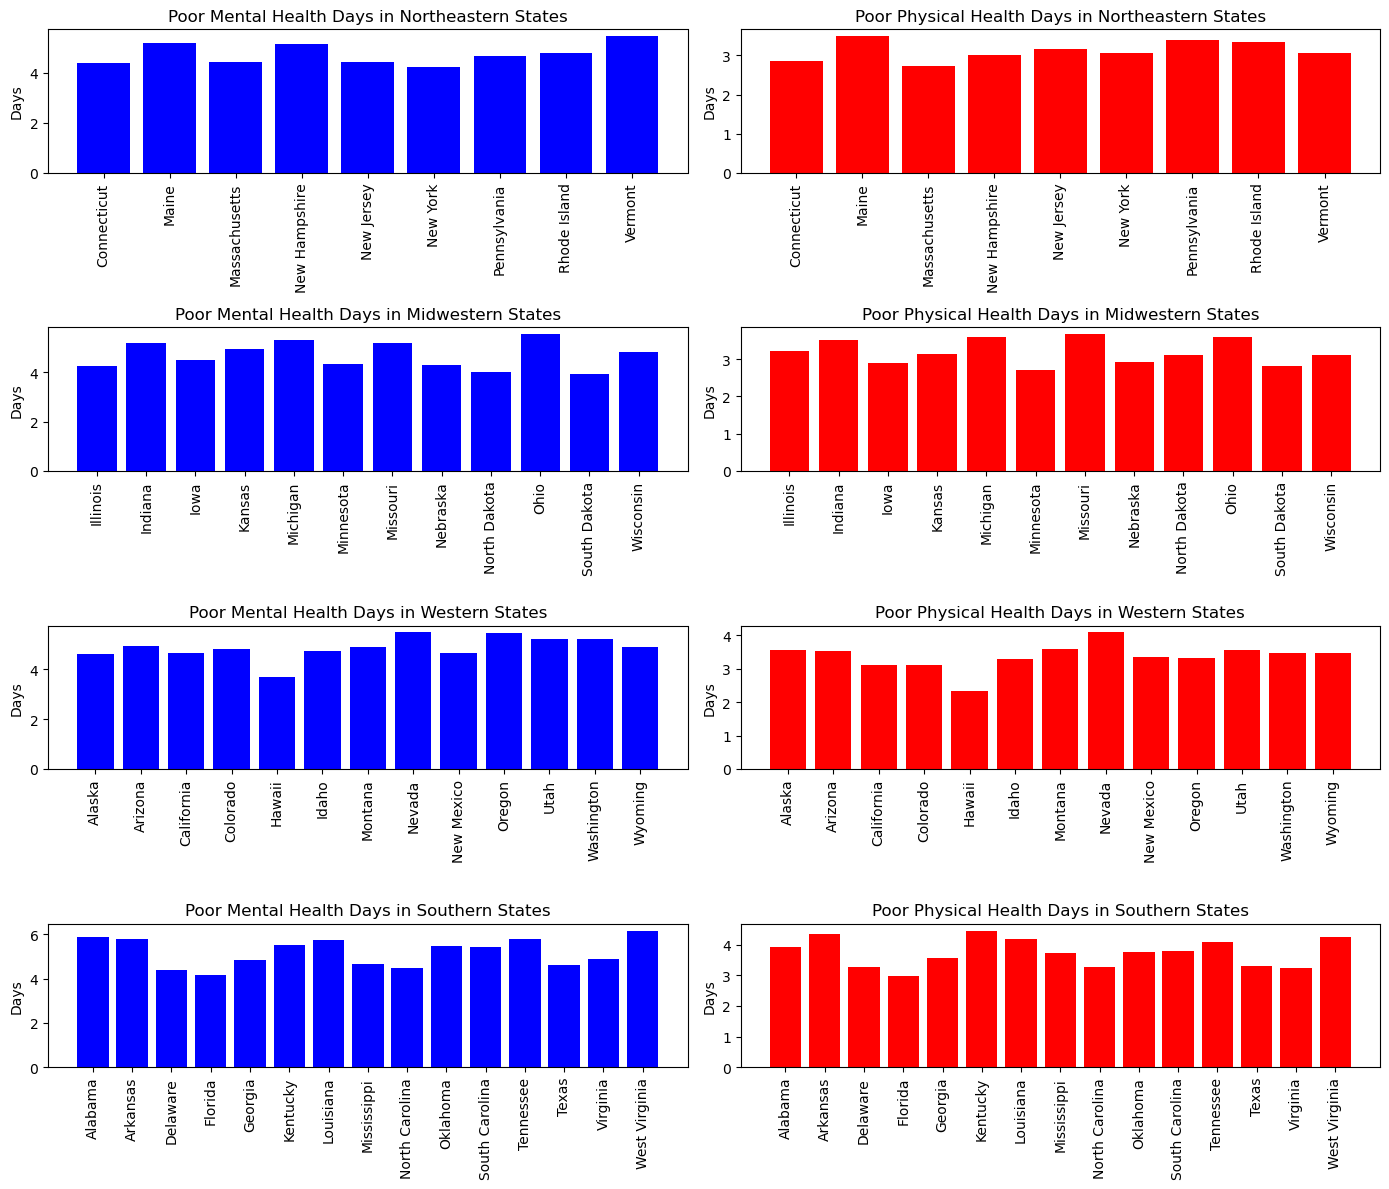

In [7]:
#standardizes the FIPs code
data['County FIPS Code'] = data['County FIPS Code'].astype(str).str.strip().str.zfill(3)
data['State FIPS Code'] = data['State FIPS Code'].astype(str).str.strip().str.zfill(2)

#divide all of the data by the region the state is in 
northeast= data[(data['County FIPS Code'] == '000') & (data['State FIPS Code'].isin(['09', '23','25', '33', '34', '36', '42', '50', '44']))].copy()
midwest= data[(data['County FIPS Code'] == '000') & (data['State FIPS Code'].isin(['17', '18', '19', '20', '26', '27', '29', '31', '38', '39', '46', '55']))].copy()
west= data[(data['County FIPS Code'] == '000') & (data['State FIPS Code'].isin(['02','04','06','08','15','16','30','32','35','41','49','53','56']))].copy()
south=  data[(data['County FIPS Code'] == '000') & (data['State FIPS Code'].isin(['01','05','12','13','21','22','28','37','40','45','47','48','51','54', '10']))].copy()

#map the state FIPs code to the state name
state_names = {
    '01': 'Alabama', '02': 'Alaska', '04': 'Arizona', '05': 'Arkansas',
    '06': 'California', '08': 'Colorado', '09': 'Connecticut',
    '10': 'Delaware', '12': 'Florida', '13': 'Georgia',
    '15': 'Hawaii', '16': 'Idaho', '17': 'Illinois', '18': 'Indiana',
    '19': 'Iowa', '20': 'Kansas', '21': 'Kentucky', '22': 'Louisiana',
    '23': 'Maine', '24': 'Maryland', '25': 'Massachusetts',
    '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi',
    '29': 'Missouri', '30': 'Montana', '31': 'Nebraska',
    '32': 'Nevada', '33': 'New Hampshire', '34': 'New Jersey',
    '35': 'New Mexico', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '40': 'Oklahoma',
    '41': 'Oregon', '42': 'Pennsylvania', '44': 'Rhode Island',
    '45': 'South Carolina', '46': 'South Dakota', '47': 'Tennessee',
    '48': 'Texas', '49': 'Utah', '50': 'Vermont',
    '51': 'Virginia', '53': 'Washington', '54': 'West Virginia',
    '55': 'Wisconsin', '56': 'Wyoming'
}
northeast['State Name'] = northeast['State FIPS Code'].map(state_names)
midwest['State Name'] = midwest['State FIPS Code'].map(state_names)
west['State Name'] = west['State FIPS Code'].map(state_names)
south['State Name'] = south['State FIPS Code'].map(state_names)

plt.subplots(4, 2, figsize=(14, 12))

#Organize region data
NE_states= northeast['State Name']
NE_mental= northeast['Poor Mental Health Days raw value']
NE_phys=northeast['Poor Physical Health Days raw value']

#plot for poor mental health days in the NE
plt.subplot(4, 2, 1)

plt.bar(NE_states, NE_mental, color='blue')
plt.title('Poor Mental Health Days in Northeastern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#plot for poor physical health days in the NE
plt.subplot(4, 2, 2)

plt.bar(NE_states, NE_phys, color='red')
plt.title('Poor Physical Health Days in Northeastern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#___Midwestern states_____________________________________________________________
MW_states= midwest['State Name']
MW_mental= midwest['Poor Mental Health Days raw value']
MW_phys=midwest['Poor Physical Health Days raw value']

#plot for poor mental health days in the MW
plt.subplot(4, 2, 3)

plt.bar(MW_states, MW_mental, color='blue')
plt.title('Poor Mental Health Days in Midwestern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#plot for poor physical health days in the MW
plt.subplot(4, 2, 4)

plt.bar(MW_states, MW_phys, color='red')
plt.title('Poor Physical Health Days in Midwestern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#_______Western states_____________________________________________________________
W_states= west['State Name']
W_mental= west['Poor Mental Health Days raw value']
W_phys=west['Poor Physical Health Days raw value']

#plot for poor mental health days in the W
plt.subplot(4, 2, 5)

plt.bar(W_states, W_mental, color='blue')
plt.title('Poor Mental Health Days in Western States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#plot for poor physical health days in the W
plt.subplot(4, 2, 6)

plt.bar(W_states, W_phys, color='red')
plt.title('Poor Physical Health Days in Western States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#______Southern states_____________________________________________________________
S_states= south['State Name']
S_mental= south['Poor Mental Health Days raw value']
S_phys= south['Poor Physical Health Days raw value']

#plot for poor mental health days in the S
plt.subplot(4, 2, 7)

plt.bar(S_states, S_mental, color='blue')
plt.title('Poor Mental Health Days in Southern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

#plot for poor physical health days in the S
plt.subplot(4, 2, 8)

plt.bar(S_states, S_phys, color='red')
plt.title('Poor Physical Health Days in Southern States')
plt.ylabel('Days')
plt.xticks(rotation=90)
plt.tight_layout()

**Explanation:**  In this graph I seperated all the data by region, categorizing them and creating variables to hold the features of interest to make the graphing process easier. For the graphs itself, I did a side by side graph for each region which plotted poor mental health days and poor physical health days for each region and labeled by state. We did this in order to see the trends by region and see if there were any patterns or correlations that stood out to us. Also by having them side by side, we could compare the two health areas and see if there were any differences between the two realms. 


## 3. Asking the Hard Questions

By now we should know all of the ins and outs about this dataset (right?). Let's dive a little deeper into it and see if we can find anything interesting.

### Problem 4

As you worked through the initial data processing and understanding phase, did anything catch your interest? Let's formulate some questions and hypotheses that you could explore in depth.

**Write-up!** Formulate and describe a question you have/want to investigate. Then, formulate and describe a hypothesis that can (possibly) answer it. What inspired your idea (provide specifics from [the last section](#2.-Getting-Familiar-with-the-Data), if any)? How can you use the data to support or reject your hypothesis?

> **Hint**: Your question/hypothesis might be something that you are personally interested in or something that you think might lead to a product or service for users/customers. You might want to think about something that could help others in making decisions, etc.

*Grading Note: Your work will be graded for _creativity_. Be creative in the questions you ask/hypothesis you pose.* 

**Answer here:** (feel free to make multiple cells!)

*Questions based on pre-graph (problem 3) observations

Question 1: Are there similarities or correlation between average poor physical health and poor mental health based on region? 

Question 2: Using the data above, can we create a ML model that can predict what region health data is coming from based on their average poor physical health and poor mental health days. 

Question 3: If we look at neighboring counties across the state lines, do we see a sharp jump in reported mental health days despite having very similar physical health rates? To what extent does this differ, and can we see any notable differences between the regions?

Hypothesis: We hypothesize that while South and Midwestern regions display a lower reported averages of poor mental health days in certain rural countries, this does not necessarily indicate better mental health rates within the region, as this can be driven by a stigma around a higher cultural reporting threshold. We predict that the North and Western regions will give us a higher reported "poor health days" because of the cultural norms are biased towards prompting mental health awareness.

### Problem 5

**Do this!** Let's explore your hypothesis. Find evidence from the data that supports or refutes your hypothesis and present it — recall that as a data scientist, one of your goals is to discover and communicate your results to your audience, _me_. The more thorough your analysis, the better!

> **Hint**: Even though we focus on EDA here, you may include some predictive modeling here as well. 

Here's yet another _free_ cell; use as many as you need.

In [8]:
# woah! these things are falling from the sky or something

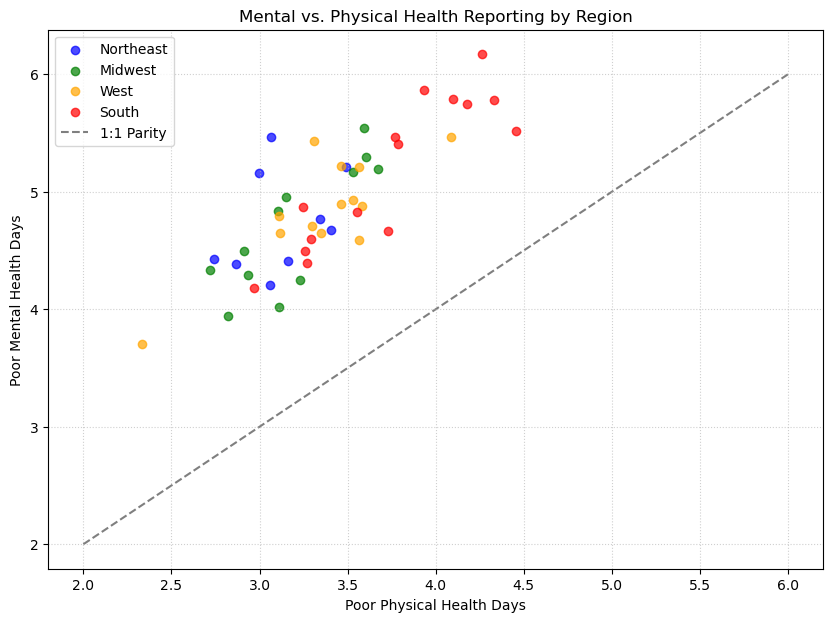

In [9]:
#setting up the plot
plt.figure(figsize=(10, 7))

#plot each region with different colors
plt.scatter(northeast['Poor Physical Health Days raw value'], northeast['Poor Mental Health Days raw value'], color='blue', label='Northeast', alpha=0.7)
plt.scatter(midwest['Poor Physical Health Days raw value'], midwest['Poor Mental Health Days raw value'], color='green', label='Midwest', alpha=0.7)
plt.scatter(west['Poor Physical Health Days raw value'], west['Poor Mental Health Days raw value'], color='orange', label='West', alpha=0.7)
plt.scatter(south['Poor Physical Health Days raw value'], south['Poor Mental Health Days raw value'], color='red', label='South', alpha=0.7)

#parity line for reference, for us to see if the points (above the line mean: more mental health days)(below the line mean more physical health days)
lims = [2, 6] 
plt.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='1:1 Parity')

#graph 
plt.title('Mental vs. Physical Health Reporting by Region')
plt.xlabel('Poor Physical Health Days')
plt.ylabel('Poor Mental Health Days')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Problem 6

**Write up!** Did you find anything interesting in [Problem 5](#Problem-5)? If you did, tell me about it. If you don't think you found anything interesting, keep looking. 

> **Hint**: Provide links to key figures in your discussion. See [this StackOverflow question](https://stackoverflow.com/questions/28080066/how-to-reference-a-ipython-notebook-cell-in-markdown) for details.

**Answer here:** (feel free to make multiple cells!)

Since we can see that most of the dots follow a clear linear path that appears above the 1:1 parity line. This means that generally physical and mental health are linked but not in a 1:1 ratio. Because all the data points are above, it means that, generally, every region show data supporting more poor mental health days taken vs poor physical health days. It's interesting that all the states seem to be have similar data and that they follow such a clear linear pattern. Since we do not see a "bottom heavy" pattern with the red dots which represent the South regions, this would not support our hypothesis when compared to the other colored region data points. 

### Problem 7
One last step that we shouldn't skip is reviewing both our data analysis approach and also the data acquisition method. 

**Write up!** Are there any **shortcommings** related to the way you used or processed this data? How about the methods/arguments you used to form your conclusions?

**Answer here:** Since we based it on the aggregate data based on state, it can be easy to generalize by region and lose some more descriptive/specific data, like if we based it on by county or even just by state. 

We also could run into shortcomings because we used the raw values rather than the confidence interval values. There can be discrepencies in the raw values that are improved upon based on the confidence intervals or there can be some bias in the values such as if the data undervalues or measures less accurately smaller, more rural counties. 

Also since we divided it by region, regions like the South have more states than other regions like the Northeast that can affect the way our data actually can be used to accurately predict/find correlations between region and poor mental/physical health.  

**Answer here:** (feel free to make multiple cells!)

**Write up!** Let's critcially review our work in the light of **ethical data science**. 
* Name at least two ethical issues related to the way you used or processed this data and/or the methods/arguments you used to form your conclusions.
* Who are the stakeholders?
* How could someone other than yourself be impacted by any ethical issues arising from your analysis/work/product?
* Propose a way to resolve the issue(s).

**Answer here:** (feel free to make multiple cells!)

**Answer here:** Some ethical issues related to the data we used are that this information can be used to harm others and could be used to discriminate against people. 

This could be used to harm others as companies can use this data in order to limit the days workers are able to take off due to poor mental or physical health. They could use the data as the framework for how many days on average people take off for either issue and then apply it as the limit for their company. If that limit is less than the previous, or just a small number in general, this can harm workers by forcing them to come into work injured/when they aren't doing well mentally or remove accommodations away from individuals who might need more sick days. 

This also could violate take action not to discriminate because depending on the usage of the data, it could be used to discriminate against smaller counties, even indirectly like if the data gathering method isn't designed to accomodate for smaller communities so it ends up misrepresenting more rural counties and that misrepresentation can then bleed into our analysis or the machine learning model that is trained by that data. 

Let's conclude with thinking about **imporvements for the future**! 

**Write up!** There are often times where the data you need doesn't exist (yet) and you need to go collect it. Based on your analysis of the data set, which features were informative and which weren't? What information that was missing from this dataset do you think would be helpful to have for next time?

**Answer here:** (feel free to make multiple cells!)

**Answer here:** In the dataset, there were a lot of descriptive variables that are related to a community’s health outcomes or environmental conditions that showed a practical relationship with overall community well-being and were a valid assessment to be used. These variables, like median household income, uninsured adults, poor or fair health raw value, and mental healthy days, helped explain trends and patterns within disparities when comparing and contrasting counties and populations.

Some things in the dataset that did not help were the large amounts of missing data. It made the cleaning process a bit more tedious than it could have been. However, some features were less informative or gave us duplicated demographic breakdowns that were not very useful during our comparisons, such as confidence interval columns. These do come in handy when comparing statistical details about the population at hand, but they do not always convey findings that we do not already know.

For the future, it would be beneficial to see if we can get a larger-scale database, not only in the sense of geographical distance but also longevity, over a couple of years or decades to see how different counties fare over time and whether they individually develop their own trends.

### Problem 8

**Write up!** Did you use any generative AI tools (ChatGPT, Copilot, etc.) for this project?
* Which generative AI tools did you use?
* How did you them? 
* How did you ensure that your project reflects your own understanding?
* What challenges or adjustments did you encounter when using generative AI (refining prompts, verifying accuracy, revising outputs, etc.)?

**Answer here:** (feel free to make multiple cells!)

We both used chatGPT. 

Amy: I used it to debug and problem solve some of the errors I ran into while I was coding. I only did used it after I tried to debug and work through it by myself first. I also made sure that I only used code I understood and that matched what we were doing in class. Since the prompts were based on my own code that was based on what we did in class, it was relatively easy to understand the changes AI made. There were some issues with the AI giving me code that used methods that we didn't talk about in class or that just didn't work, so then I just had to pivot my thinking and change what I wanted to do. Once I did that, I could work through it myself and only used AI if I ran into any errors I didn't understand. 

Anu: I used it to preform some troubleshooting when my git pull and push aborted in the terminal. Amy pushed all her code to the main branch on the git repository, and when I pulled it, the terminal gave me an error. I had to promt chatgpt to help me purely pull Amy's code and change my edits with the command  "git reset --hard origin/main" which I had not used before. I also prompted chatGPT to give me the scatterplot gragh syntax to create the region scatter plot in part 5 and the counties scatter plot part 2. I used only used it for the formatting of the scatter plot not inputting the parameters. I also used it find the most asethetic color pallet for the legend colors used in part 2. I also used chatgpt to help me with my grammer and spell check. 

### Problem 9

**Write up!** What was your division of work plan?
* Which partner did which sections?
* Was the work split evenly?

Me and Anu split the work pretty evenly with each of us either working on one whole problem ourselves, or part of one problem.

We worked together on problem 1, 4, 6, and problem 7. 

Amy: I did problem 2 and the bar plot for problem 3

Anu: I did the scatter plot on problem 3 and problem 5

**Answer here:** (feel free to make multiple cells!)

And that's it! Remember to review your work and make sure it is well presented and organized. Not everyting you coded up needs to remain in your submission. **[Does [this cell] spark joy?](https://i.kinja-img.com/gawker-media/image/upload/s--iW_3HGbT--/c_scale,dpr_2.0,f_auto,fl_progressive,q_80,w_800/oruf4oavtj5vpmvaquew.jpg)** You are always trying to communicate your findings to somebody, _maybe even yourself_. 

> **Final Grading Note/Reminder**: Your work will be graded for _creativity_, _aesthetics_, _readability_, _style_, and _cleanlines_. So, carefully document your code and use descriptive/intuitive variable names. For write-ups use consice and clear language like in a written project report. Be creative in the questions you ask/hypothesis you pose as well as in the plots you use and select visulatizations and colors that make for a plesant and intuitive viewing expereince. The goal of a good visualization is that the viewer will quickly understand your figures. 

### Submission instructions
* Check to make sure that your code runs without error on a fresh kernel. Within jupyter, **Kernel -> Restart & Run All**. 
* **Save your notebook!**
* Submit this Python notebook, including your answers in the code cells as homework submission. Be sure to add your partner to the submission as well.
* After submitting, navigate to the **code tab** to view your submission. Verify that all your write-ups, markdown cells, and visualizations appear correctly on Gradescope. This is the **exact** view the graders will see when grading your work, so make sure that everything looks as expected.

In [10]:
grader.check("hw6")

hw6 results: All test cases passed!

<!-- END QUESTION -->

